In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import jarque_bera

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.4f}".format)

# NS yield function (copied from notebook 01 — no import dependency)
def ns_yield(tau, beta0, beta1, beta2, lam=1.9675):
    tau = np.maximum(tau, 1e-6)
    factor = (1 - np.exp(-tau / lam)) / (tau / lam)
    return beta0 + beta1 * factor + beta2 * (factor - np.exp(-tau / lam))

FIXED_LAM = 1.9675

TENOR_YEARS = {
    "1mo": 1/12, "3mo": 3/12, "6mo": 6/12,
    "1yr": 1, "2yr": 2, "3yr": 3, "5yr": 5,
    "7yr": 7, "10yr": 10, "20yr": 20, "30yr": 30,
}
TAUS = list(TENOR_YEARS.values())

In [3]:
yields  = pd.read_csv("data/yields_clean.csv",  index_col="date", parse_dates=True)
ns_dl   = pd.read_csv("data/ns_params_dl.csv",  index_col="date", parse_dates=True)

# Keep only the three factors
factors = ns_dl[["beta0", "beta1", "beta2"]].copy()
factors.columns = ["L", "S", "C"]   # Level, Slope, Curvature

print(f"Yields  : {yields.shape}")
print(f"Factors : {factors.shape}")
print(f"Date range: {factors.index.min()} → {factors.index.max()}")
factors.tail()

Yields  : (6851, 11)
Factors : (6851, 3)
Date range: 2000-01-03 00:00:00 → 2026-04-06 00:00:00


,L,S,C
date,,,
2026-03-31,5.1047,-1.3113,-2.2739
2026-04-01,5.1332,-1.3496,-2.1987
2026-04-02,5.1015,-1.3215,-2.2059
2026-04-03,5.1159,-1.3425,-2.0282
2026-04-06,5.0939,-1.3101,-2.0188


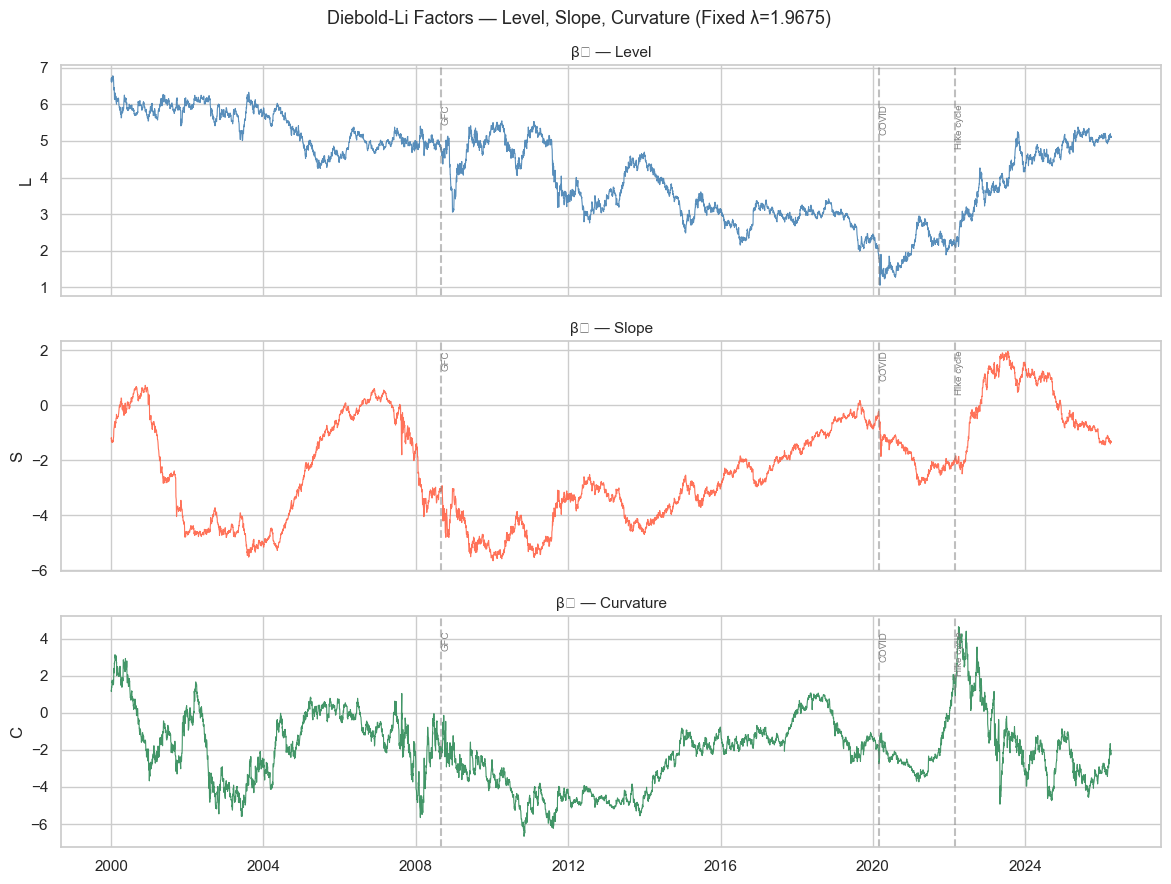

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

meta = [
    ("L", "β₀ — Level",     "steelblue"),
    ("S", "β₁ — Slope",     "tomato"),
    ("C", "β₂ — Curvature", "seagreen"),
]
regimes = [
    ("2008-09-01", "GFC"),
    ("2020-03-01", "COVID"),
    ("2022-03-01", "Hike cycle"),
]

for ax, (col, title, color) in zip(axes, meta):
    ax.plot(factors.index, factors[col], color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(col)
    ax.set_title(title, fontsize=11)
    for rd, rl in regimes:
        ax.axvline(pd.Timestamp(rd), color="gray", linestyle="--", alpha=0.5)
        ax.text(pd.Timestamp(rd), ax.get_ylim()[1]*0.85, rl,
                fontsize=7, color="gray", rotation=90, va="top")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Diebold-Li Factors — Level, Slope, Curvature (Fixed λ=1.9675)", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_dl_factors.png", dpi=150)
plt.show()

Factor proxy correlations:
  Level     vs 30yr yield         : 0.980
  Slope     vs -(30yr-3mo)        : 0.998
  Curvature vs 2×2yr-3mo-30yr     : 0.919


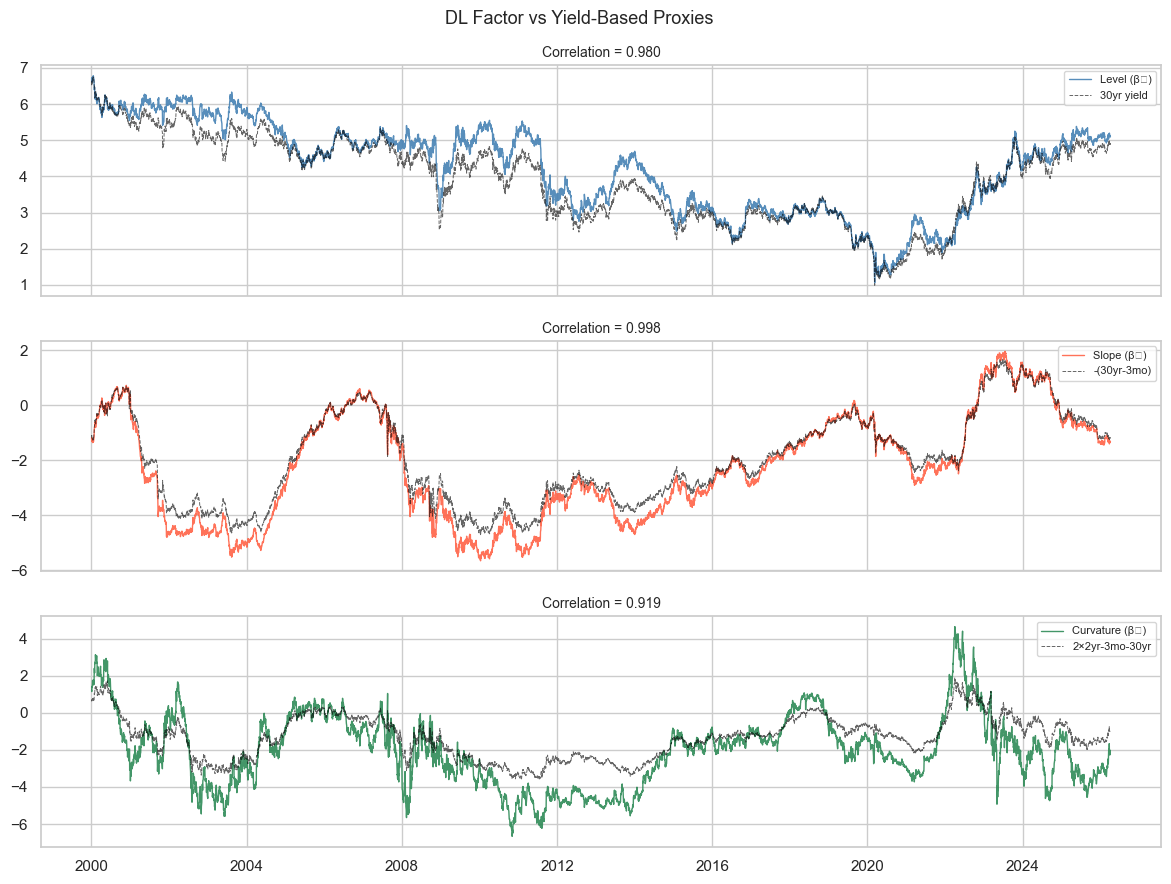

In [5]:
# Diebold-Li interpretation:
#   Level     ≈ 30yr yield
#   Slope     ≈ -(30yr - 3mo)   [negative because beta1 is negative for upward curve]
#   Curvature ≈ 2×2yr - 3mo - 30yr

level_proxy = yields["30yr"]
slope_proxy = -(yields["30yr"] - yields["3mo"])
curve_proxy = 2*yields["2yr"] - yields["3mo"] - yields["30yr"]

# Align indices
idx = factors.index.intersection(yields.index)
f   = factors.loc[idx]
lp  = level_proxy.loc[idx]
sp  = slope_proxy.loc[idx]
cp  = curve_proxy.loc[idx]

corr_L = f["L"].corr(lp)
corr_S = f["S"].corr(sp)
corr_C = f["C"].corr(cp)

print("Factor proxy correlations:")
print(f"  Level     vs 30yr yield         : {corr_L:.3f}")
print(f"  Slope     vs -(30yr-3mo)        : {corr_S:.3f}")
print(f"  Curvature vs 2×2yr-3mo-30yr     : {corr_C:.3f}")

# Visual comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
pairs = [
    ("L", lp, "Level (β₀)",     "30yr yield",        "steelblue"),
    ("S", sp, "Slope (β₁)",     "-(30yr-3mo)",        "tomato"),
    ("C", cp, "Curvature (β₂)", "2×2yr-3mo-30yr",     "seagreen"),
]
for ax, (fcol, proxy, flabel, plabel, color) in zip(axes, pairs):
    ax.plot(f.index, f[fcol],   color=color,  linewidth=1,   label=flabel, alpha=0.9)
    ax.plot(proxy.index, proxy, color="black", linewidth=0.7, label=plabel, alpha=0.6, linestyle="--")
    ax.legend(fontsize=8)
    ax.set_title(f"Correlation = {f[fcol].corr(proxy):.3f}", fontsize=10)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("DL Factor vs Yield-Based Proxies", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_dl_factor_proxies.png", dpi=150)
plt.show()

In [6]:
print("Augmented Dickey-Fuller Tests (H0: unit root exists)")
print("-" * 55)
for col in ["L", "S", "C"]:
    result = adfuller(factors[col].dropna(), autolag="AIC")
    stat, pval, _, _, crit = result[0], result[1], result[2], result[3], result[4]
    conclusion = "Stationary" if pval < 0.05 else "Non-stationary"
    print(f"  {col}: ADF={stat:.3f}  p={pval:.4f}  [{conclusion}]")
    print(f"       Critical values: 1%={crit['1%']:.3f}  5%={crit['5%']:.3f}")

# Note: Level factor (beta0) is often non-stationary (unit root)
# This is fine for VAR — we model levels, not differences
# Diebold-Li original paper models levels directly

Augmented Dickey-Fuller Tests (H0: unit root exists)
-------------------------------------------------------
  L: ADF=-2.060  p=0.2609  [Non-stationary]
       Critical values: 1%=-3.431  5%=-2.862
  S: ADF=-1.856  p=0.3532  [Non-stationary]
       Critical values: 1%=-3.431  5%=-2.862
  C: ADF=-3.728  p=0.0037  [Stationary]
       Critical values: 1%=-3.431  5%=-2.862


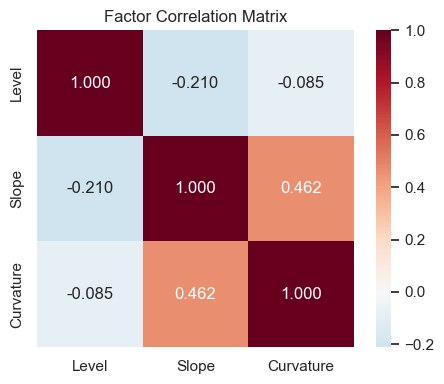

In [7]:
corr = factors.corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, ax=ax, square=True,
            xticklabels=["Level","Slope","Curvature"],
            yticklabels=["Level","Slope","Curvature"])
ax.set_title("Factor Correlation Matrix")
plt.tight_layout()
plt.savefig("data/fig_dl_corr.png", dpi=150)
plt.show()

In [8]:
# Use monthly data for VAR — daily is too noisy and slow
# Resample to month-end

factors_monthly = factors.resample("ME").last().dropna()
print(f"Monthly observations: {len(factors_monthly)}")

# Fit VAR on full sample just for lag selection
model_select = VAR(factors_monthly)
lag_results = model_select.select_order(maxlags=12)
print(lag_results.summary())

# AIC and BIC recommended lags
aic_lag = lag_results.aic
bic_lag = lag_results.bic
print(f"\nAIC recommended lag: {aic_lag}")
print(f"BIC recommended lag: {bic_lag}")
print(f"\nUsing lag=1 (standard Diebold-Li convention)")
# We use lag=1 regardless — it's the DL paper convention
# and monthly data with lag=1 is well-established in literature

Monthly observations: 316
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        2.571       2.608       13.09       2.586
1       -6.419     -6.272*    0.001630      -6.360
2       -6.475      -6.218    0.001541     -6.372*
3       -6.513      -6.146    0.001485      -6.366
4      -6.526*      -6.049   0.001465*      -6.335
5       -6.492      -5.905    0.001516      -6.257
6       -6.453      -5.756    0.001576      -6.175
7       -6.437      -5.630    0.001602      -6.114
8       -6.439      -5.522    0.001599      -6.073
9       -6.441      -5.414    0.001598      -6.030
10      -6.422      -5.285    0.001628      -5.967
11      -6.386      -5.139    0.001689      -5.887
12      -6.342      -4.985    0.001767      -5.799
--------------------------------------------------

AIC recommended lag: 4
BIC recommended lag: 1

Using lag=1 (standard Diebold-Li convention)


In [9]:
# Train/test split: hold out last 12 months for out-of-sample evaluation
n_test  = 12
n_train = len(factors_monthly) - n_test

train = factors_monthly.iloc[:n_train]
test  = factors_monthly.iloc[n_train:]

var_model  = VAR(train)
var_result = var_result = var_model.fit(maxlags=1, ic=None)
print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 08, Apr, 2026
Time:                     00:44:24
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -6.24777
Nobs:                     303.000    HQIC:                  -6.33601
Log likelihood:          -308.996    FPE:                 0.00167015
AIC:                     -6.39485    Det(Omega_mle):      0.00160571
--------------------------------------------------------------------
Results for equation L
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.106334         0.050751            2.095           0.036
L1.L          0.979386         0.011729           83.500           0.000
L1.S          0.011348         0.008837            1.284           0.199
L1.C         -0.000159 

Durbin-Watson statistics (want ~2.0 for no autocorrelation):
  L: 1.920
  S: 1.814
  C: 2.102

Jarque-Bera normality test (p>0.05 = normal residuals):
  L: stat=43.43  p=0.0000
  S: stat=55.68  p=0.0000
  C: stat=23.94  p=0.0000


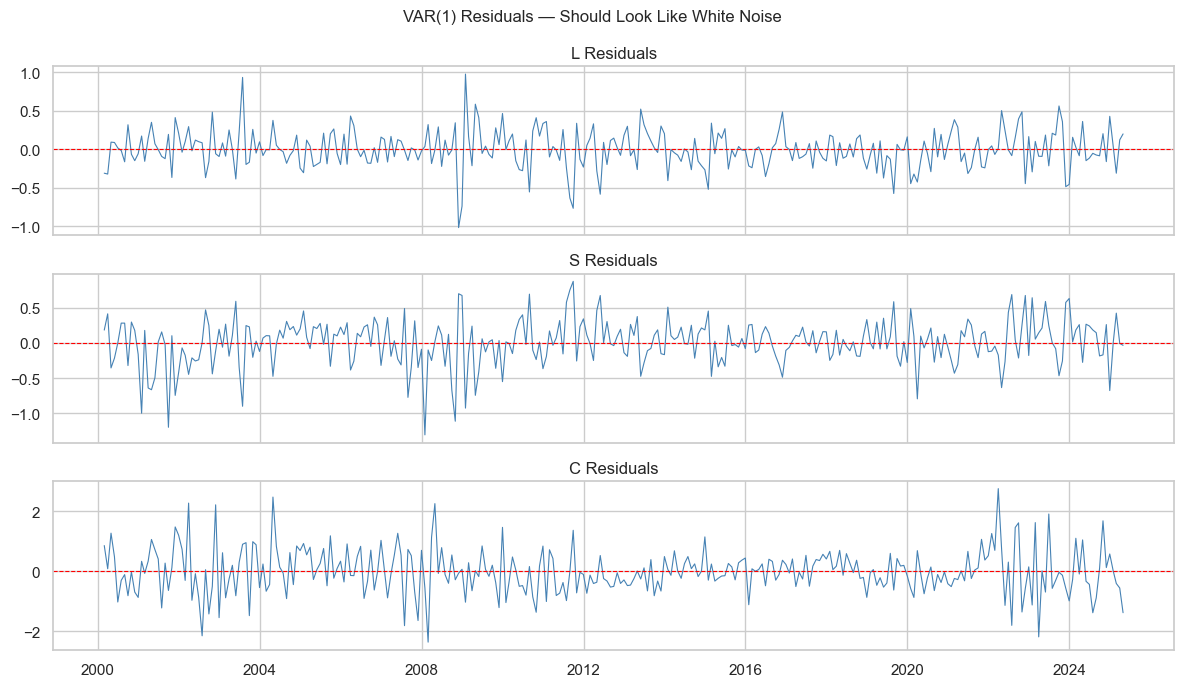

In [10]:
# Residual checks — want white noise residuals
residuals = var_result.resid

print("Durbin-Watson statistics (want ~2.0 for no autocorrelation):")
for i, col in enumerate(["L", "S", "C"]):
    dw = durbin_watson(residuals.iloc[:, i])
    print(f"  {col}: {dw:.3f}")

print("\nJarque-Bera normality test (p>0.05 = normal residuals):")
for col in ["L", "S", "C"]:
    stat, pval = jarque_bera(residuals[col])[:2]
    print(f"  {col}: stat={stat:.2f}  p={pval:.4f}")

# Residual time series plot
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, col in zip(axes, ["L", "S", "C"]):
    ax.plot(residuals.index, residuals[col], linewidth=0.8, color="steelblue")
    ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
    ax.set_title(f"{col} Residuals")
plt.suptitle("VAR(1) Residuals — Should Look Like White Noise", fontsize=12)
plt.tight_layout()
plt.savefig("data/fig_var_residuals.png", dpi=150)
plt.show()

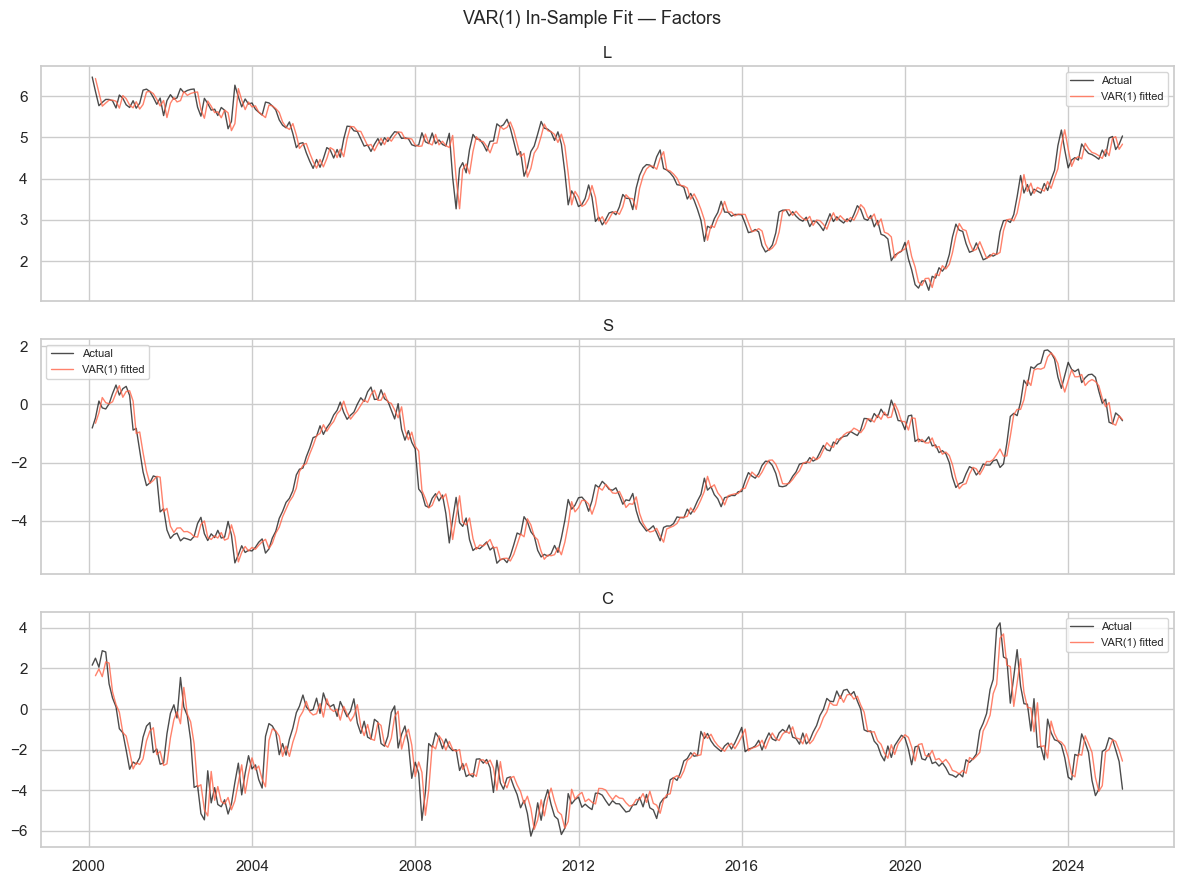

In [11]:
fitted_vals = var_result.fittedvalues

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col in zip(axes, ["L", "S", "C"]):
    ax.plot(train.index, train[col],       color="black",     linewidth=1,   label="Actual", alpha=0.7)
    ax.plot(fitted_vals.index, fitted_vals[col], color="tomato", linewidth=1, label="VAR(1) fitted", alpha=0.8)
    ax.set_title(col)
    ax.legend(fontsize=8)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("VAR(1) In-Sample Fit — Factors", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_var_insample.png", dpi=150)
plt.show()

In [12]:
# Generate 1, 3, 6 month ahead forecasts using rolling window

horizons   = [1, 3, 6]   # months ahead
forecast_records = []

# Rolling: for each month in test set, forecast h steps ahead
for h in horizons:
    for i in range(len(test)):
        # Use all data up to this point
        history = factors_monthly.iloc[:n_train + i]
        if len(history) < 10:
            continue
        m = VAR(history).fit(maxlags=1, ic=None)

        # Forecast h steps
        fc = m.forecast(history.values[-1:], steps=h)
        L_fc, S_fc, C_fc = fc[-1]   # take the h-step ahead forecast

        # Actual values h months later
        future_idx = n_train + i + h
        if future_idx >= len(factors_monthly):
            continue
        actual = factors_monthly.iloc[future_idx]

        forecast_records.append({
            "forecast_date": history.index[-1],
            "target_date":   factors_monthly.index[future_idx],
            "horizon":       h,
            "L_fc": L_fc, "S_fc": S_fc, "C_fc": C_fc,
            "L_act": actual["L"], "S_act": actual["S"], "C_act": actual["C"],
        })

forecasts_df = pd.DataFrame(forecast_records)
forecasts_df.to_csv("data/dl_var_forecasts.csv", index=False)
print(f"Forecast records: {len(forecasts_df)}")
forecasts_df.head()

Forecast records: 26


,forecast_date,target_date,horizon,L_fc,S_fc,C_fc,L_act,S_act,C_act
0,2025-04-30,2025-06-30,1,5.0318,-0.7643,-3.8065,5.1164,-0.6004,-3.8225
1,2025-05-31,2025-07-31,1,5.2171,-0.8723,-3.2748,5.1850,-0.6019,-3.4228
2,2025-06-30,2025-08-31,1,5.1129,-0.7919,-3.7012,5.3024,-0.8453,-4.5428
3,2025-07-31,2025-09-30,1,5.1810,-0.7670,-3.3386,5.0614,-0.8784,-3.5548
4,2025-08-31,2025-10-31,1,5.2961,-1.0678,-4.3804,4.9563,-0.8878,-3.1847


In [13]:
# Convert factor forecasts to yield curve forecasts
# Then compute RMSE against realized yields

def factors_to_yields(L, S, C, taus=TAUS, lam=FIXED_LAM):
    """Convert DL factors to yield curve."""
    return np.array([ns_yield(tau, L, S, C, lam) for tau in taus])

tenor_labels = list(TENOR_YEARS.keys())
rmse_records = []

for h in horizons:
    sub = forecasts_df[forecasts_df["horizon"] == h]
    tenor_errors = {t: [] for t in tenor_labels}

    for _, row in sub.iterrows():
        # Forecasted curve
        fc_curve  = factors_to_yields(row["L_fc"], row["S_fc"], row["C_fc"])
        # Actual curve on target date
        tgt_date  = row["target_date"]
        if tgt_date not in yields.index:
            # Find nearest date
            nearest = yields.index[yields.index.get_indexer([tgt_date], method="nearest")[0]]
            act_row = yields.loc[nearest]
        else:
            act_row = yields.loc[tgt_date]

        act_curve = act_row[list(TENOR_YEARS.keys())].values.astype(float)

        for i, t in enumerate(tenor_labels):
            if not np.isnan(act_curve[i]):
                tenor_errors[t].append((fc_curve[i] - act_curve[i])**2)

    row_data = {"horizon": f"{h}mo"}
    for t in tenor_labels:
        errs = tenor_errors[t]
        row_data[t] = np.sqrt(np.mean(errs)) * 100 if errs else np.nan
    rmse_records.append(row_data)

rmse_table = pd.DataFrame(rmse_records).set_index("horizon")
print("Forecast RMSE by tenor and horizon (bps):")
print(rmse_table.round(1).to_string())

Forecast RMSE by tenor and horizon (bps):
            1mo     3mo     6mo     1yr     2yr     3yr     5yr     7yr    10yr    20yr    30yr
horizon                                                                                        
1mo     12.7000 17.1000 19.6000 18.8000 24.0000 23.2000 18.9000 17.5000 16.4000 20.9000 16.5000
3mo     24.4000 22.8000 23.2000 25.4000 31.1000 29.3000 21.9000 19.3000 16.9000 20.5000 15.1000
6mo     36.2000 35.2000 39.8000 41.1000 47.4000 42.8000 30.7000 24.9000 18.9000 21.9000 13.1000


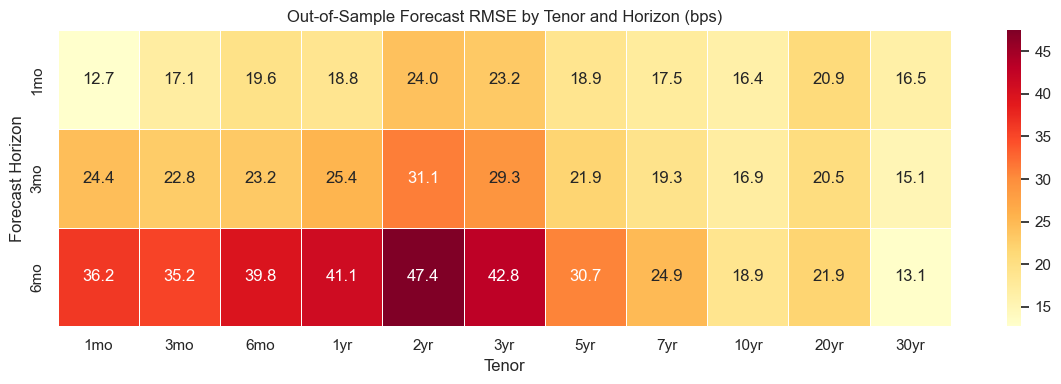


Hardest tenor to forecast: 2yr (34.2bps avg)
Easiest tenor to forecast: 30yr (14.9bps avg)


In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(rmse_table.astype(float), annot=True, fmt=".1f",
            cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Out-of-Sample Forecast RMSE by Tenor and Horizon (bps)")
ax.set_xlabel("Tenor")
ax.set_ylabel("Forecast Horizon")
plt.tight_layout()
plt.savefig("data/fig_forecast_rmse_heatmap.png", dpi=150)
plt.show()

# Identify hardest tenor to forecast
avg_rmse = rmse_table.mean()
print(f"\nHardest tenor to forecast: {avg_rmse.idxmax()} ({avg_rmse.max():.1f}bps avg)")
print(f"Easiest tenor to forecast: {avg_rmse.idxmin()} ({avg_rmse.min():.1f}bps avg)")

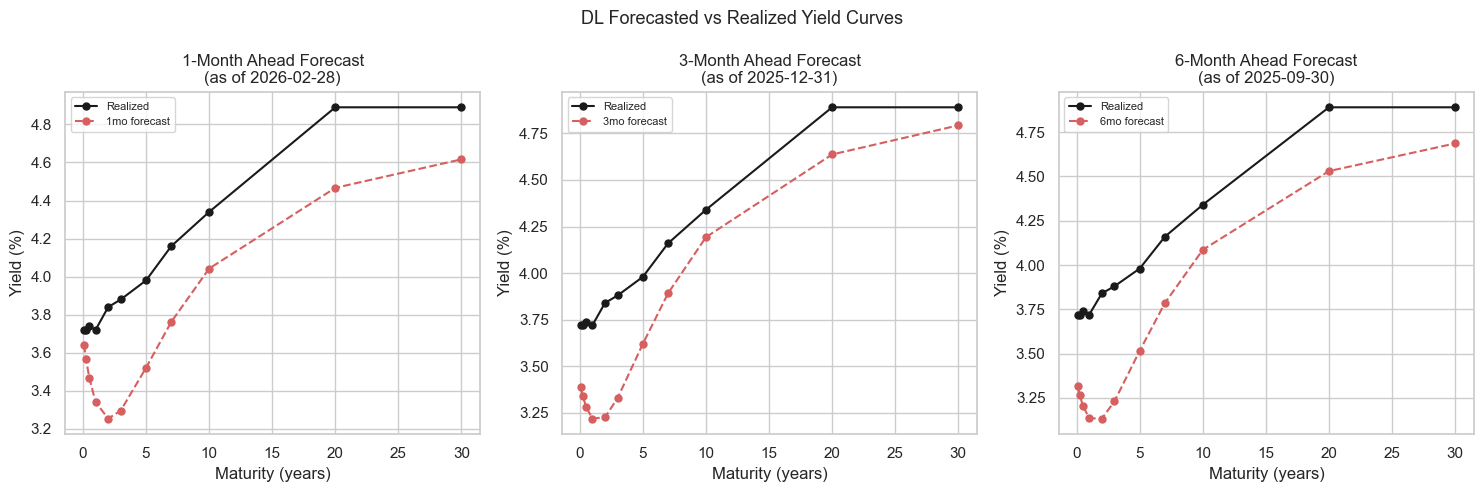

In [15]:
# Plot forecasted vs realized yield curve for last 3 test dates

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, h in zip(axes, horizons):
    sub = forecasts_df[forecasts_df["horizon"] == h].tail(1).iloc[0]
    fc_curve  = factors_to_yields(sub["L_fc"], sub["S_fc"], sub["C_fc"])

    tgt = sub["target_date"]
    if tgt not in yields.index:
        nearest = yields.index[yields.index.get_indexer([tgt], method="nearest")[0]]
        act_row = yields.loc[nearest]
    else:
        act_row = yields.loc[tgt]
    act_curve = act_row[list(TENOR_YEARS.keys())].values.astype(float)

    ax.plot(TAUS, act_curve, "ko-", markersize=5, label="Realized", linewidth=1.5)
    ax.plot(TAUS, fc_curve,  "r--o", markersize=5, label=f"{h}mo forecast", linewidth=1.5)
    ax.set_title(f"{h}-Month Ahead Forecast\n(as of {sub['forecast_date'].date()})")
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=8)

plt.suptitle("DL Forecasted vs Realized Yield Curves", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_forecast_curves.png", dpi=150)
plt.show()

In [16]:
# Simulate 10,000 paths of (L, S, C) over 12 months
# Uses VAR(1) fitted on full sample + bootstrapped residuals

np.random.seed(42)
N_PATHS  = 10_000
N_STEPS  = 12   # months

# Refit VAR on full monthly sample
var_full   = VAR(factors_monthly).fit(maxlags=1, ic=None)
coef       = var_full.coefs[0]          # 3×3 AR coefficient matrix
intercept  = var_full.intercept         # 3-vector
resid_cov  = var_full.sigma_u           # 3×3 residual covariance

last_obs   = factors_monthly.values[-1]  # starting point

# Simulate paths
paths = np.zeros((N_PATHS, N_STEPS + 1, 3))
paths[:, 0, :] = last_obs

for t in range(1, N_STEPS + 1):
    shocks = np.random.multivariate_normal(np.zeros(3), resid_cov, size=N_PATHS)
    paths[:, t, :] = intercept + paths[:, t-1, :] @ coef.T + shocks

print(f"Simulated {N_PATHS} paths × {N_STEPS} steps")
print(f"Final step L: mean={paths[:,-1,0].mean():.3f}  std={paths[:,-1,0].std():.3f}")
print(f"Final step S: mean={paths[:,-1,1].mean():.3f}  std={paths[:,-1,1].std():.3f}")
print(f"Final step C: mean={paths[:,-1,2].mean():.3f}  std={paths[:,-1,2].std():.3f}")

# Save a sample of paths (1000) to CSV — full 10K is too large
sample_paths = paths[::10, :, :]   # every 10th path = 1000 paths
paths_flat = sample_paths.reshape(1000, -1)
cols = [f"{fac}_t{t}" for t in range(N_STEPS+1) for fac in ["L","S","C"]]
pd.DataFrame(paths_flat, columns=cols).to_csv("data/dl_mc_paths.csv", index=False)

Simulated 10000 paths × 12 steps
Final step L: mean=4.939  std=0.720
Final step S: mean=-1.857  std=1.015
Final step C: mean=-2.388  std=1.712


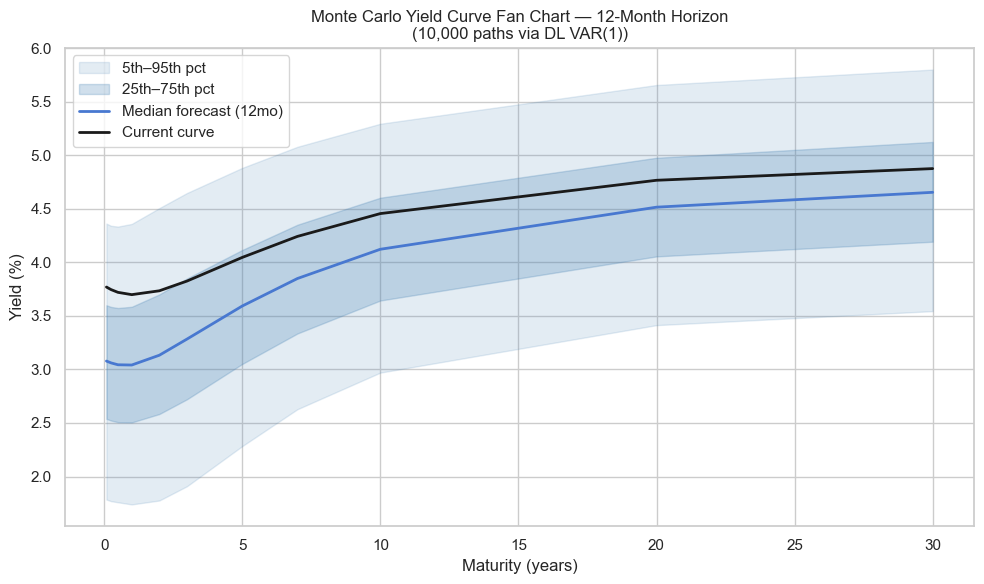

Saved MC envelopes to data/dl_mc_yield_envelopes.csv


In [17]:
#── CELL 16: Monte Carlo Fan Chart ───────────────────────────
# Convert all MC paths at final step to yield curves
# Build 5th/95th percentile envelopes across the curve

pct_levels = [5, 25, 50, 75, 95]
envelope   = {p: [] for p in pct_levels}

for tau in TAUS:
    # For each maturity, get distribution of yields across all paths at 12mo
    yields_at_tau = np.array([
        ns_yield(tau, paths[i, -1, 0], paths[i, -1, 1], paths[i, -1, 2])
        for i in range(N_PATHS)
    ])
    for p in pct_levels:
        envelope[p].append(np.percentile(yields_at_tau, p))

# Current curve for reference
current_curve = factors_to_yields(last_obs[0], last_obs[1], last_obs[2])

fig, ax = plt.subplots(figsize=(10, 6))

# Shaded bands
ax.fill_between(TAUS, envelope[5],  envelope[95], alpha=0.15, color="steelblue", label="5th–95th pct")
ax.fill_between(TAUS, envelope[25], envelope[75], alpha=0.25, color="steelblue", label="25th–75th pct")
ax.plot(TAUS, envelope[50],  "b-",  linewidth=2, label="Median forecast (12mo)")
ax.plot(TAUS, current_curve, "k-",  linewidth=2, label="Current curve")

ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield (%)")
ax.set_title("Monte Carlo Yield Curve Fan Chart — 12-Month Horizon\n(10,000 paths via DL VAR(1))")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_mc_fan_chart.png", dpi=150)
plt.show()

# Save envelopes
env_df = pd.DataFrame(envelope, index=list(TENOR_YEARS.keys()))
env_df.columns = [f"p{p}" for p in pct_levels]
env_df.to_csv("data/dl_mc_yield_envelopes.csv")
print("Saved MC envelopes to data/dl_mc_yield_envelopes.csv")

In [18]:
# ── CELL 17: Validation Checklist ────────────────────────────
print("=" * 55)
print("VALIDATION CHECKLIST — NOTEBOOK 02")
print("=" * 55)

print(f"\n[{'PASS' if corr_L > 0.85 else 'FAIL'}] "
      f"Level factor corr with 30yr yield    : {corr_L:.3f}")
print(f"[{'PASS' if corr_S > 0.85 else 'FAIL'}] "
      f"Slope factor corr with -(30yr-3mo)   : {corr_S:.3f}")
print(f"[{'PASS' if corr_C > 0.70 else 'FAIL'}] "
      f"Curvature factor corr with proxy     : {corr_C:.3f}")

avg_1mo = rmse_table.loc["1mo"].mean()
avg_6mo = rmse_table.loc["6mo"].mean()
print(f"\n[{'PASS' if avg_6mo > avg_1mo else 'NOTE'}] "
      f"6mo RMSE > 1mo RMSE (harder to forecast farther out)")
print(f"  1mo avg RMSE: {avg_1mo:.1f}bps")
print(f"  6mo avg RMSE: {avg_6mo:.1f}bps")

belly_rmse = rmse_table[["2yr","5yr","7yr"]].mean(axis=1).mean()
short_rmse = rmse_table[["1mo","3mo","6mo"]].mean(axis=1).mean()
long_rmse  = rmse_table[["20yr","30yr"]].mean(axis=1).mean()
print(f"\n[NOTE] RMSE by curve segment:")
print(f"  Short end  : {short_rmse:.1f}bps")
print(f"  Belly      : {belly_rmse:.1f}bps")
print(f"  Long end   : {long_rmse:.1f}bps")

print(f"\nOutputs saved to data/:")
print("  dl_factors.csv, dl_var_forecasts.csv")
print("  dl_mc_paths.csv, dl_mc_yield_envelopes.csv")
print("  fig_*.png (7 plots)")
print("\nNotebook 02 complete. Feed dl_mc_yield_envelopes.csv into notebook 03.")

VALIDATION CHECKLIST — NOTEBOOK 02

[PASS] Level factor corr with 30yr yield    : 0.980
[PASS] Slope factor corr with -(30yr-3mo)   : 0.998
[PASS] Curvature factor corr with proxy     : 0.919

[PASS] 6mo RMSE > 1mo RMSE (harder to forecast farther out)
  1mo avg RMSE: 18.7bps
  6mo avg RMSE: 32.0bps

[NOTE] RMSE by curve segment:
  Short end  : 25.7bps
  Belly      : 26.2bps
  Long end   : 18.0bps

Outputs saved to data/:
  dl_factors.csv, dl_var_forecasts.csv
  dl_mc_paths.csv, dl_mc_yield_envelopes.csv
  fig_*.png (7 plots)

Notebook 02 complete. Feed dl_mc_yield_envelopes.csv into notebook 03.
